# Homework 6 Coding Part 2 - REINFORCE and REINFORCE with Baseline

## CartPole Problem (REINFORCE and REINFORCE with Baseline)

In this assignment, we will solve the "CartPole-v1" task from the OpenAI Gym using REINFORCE algorithms.

### Problem Desciption

A pole is attached by an un-actuated joint to a cart, which moves along a frictionless track. The system is controlled by applying a force of +1 or -1 to the cart. The pendulum starts upright, and the goal is to prevent it from falling over.


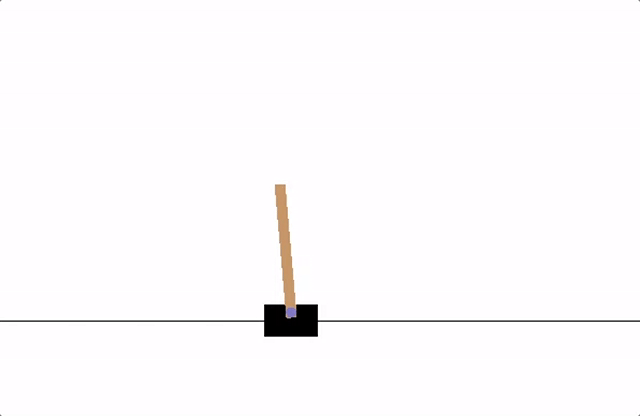




### Formulation

- *State* $s$:
    The state consists of four observations as follows:

|Num|Observation|Min|Max|
|:-:|:-:|:-:|:-:|
|0|Cart Position|-4.8|4.8|
|1|Cart Velocity|-Inf|Inf|
|2|Pole Angle|-0.418 rad(-24 deg)|0.418 rad (24 deg)|
|3|Pole Angular Velocity|-Inf|Inf|

All observations of the initial state are assigned a uniform random value in [-0.05,0.05].


- *Action $a$*:
    There are two possible actions as follows:

|Num|Action|
|:-:|:-:|
|0|Push cart to the left|
|1|Push cart to the right|


- *Reward $r(s,a)$*:
    
    Reward is 1 for every step taken, including the termination step.
    

- Episode Termination

    An episode terminates when one of the following occurs:
  - Pole Angle is more than 12 degrees.
  - Cart Position is more than 2.4 (Cart reaches the edge of the display).
  - Episode length is greater than 500.


- *Objective*:

    The CarPole problem is considered solved when the average return is greater than or equal to 475.0 over 100 consecutive trials (episodes).


In [ ]:
# Import packages. Run this cell.

import numpy as np
import gym
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import deque
import random

### Tasks

There are two tasks, where we will use REINFORCE and REINFORCE with baseline to solve the "CartPole-v1" problem.

**1.** **REINFORCE** (20 points)

We will use REINFORCE algorithm (without baseline) to solve the CartPole problem.

Please complete functions  ``select_action(self, state)`` and  ``train(self, state_list, action_list, reward_list, done_list)`` in the class ``REINFORCE``.
   - ``select_action(self, state)`` will be called each step and returns an action for the agent to take.
   - ``train(self, state_list, action_list, reward_list, done_list)`` will be called at the end of each episode.
       - `state_list`: a list of states in this episode.
       - `action_list`: a list of actions in this episode.
       - `reward_list`: a list of rewards in this episode.
       - `done_list`: a list of Boolean values. If the episode terminates at step `i`, `done_list[i] = True`; Otherwise, `done_list[i] = False`.
       - Note that `state_list` is one step longer than others
   
You can also add or revise classes and functions if you need.

**Note**:
You can use neural network and the Gibbs policy. A small neural network is enough for this problem. The platform does not support GPU, so please use CPU.

**Recommended Hyperparameters**:
- Discount factor: 0.99
- For the policy network, you can use the class `PolicyNetwork` with `hidden_dim=128`
- Optimizer: Adam
- Learning rate: 0.0001

In [ ]:
"""
A simple policy network
"""
class PolicyNetwork(nn.Module):
    def __init__(self, input_dim, output_dim, hidden_dim):
        """
        Args:
            input_dim (int): state dimension.
            output_dim (int): number of actions.
            hidden_dim (int): hidden layer dimension (fully connected layer)
        """
        super().__init__()
        self.linear1 = nn.Linear(input_dim, hidden_dim)
        self.linear2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, state):
        """
        Returns a distribution over actions
        Args:
            state (torch.Tensor): state, 2-D tensor of shape (n, input_dim)
        Returns:
            torch.Tensor: probabilities for the actions, 2-D tensor of shape (n, output_dim)
        """
        x = F.relu(self.linear1(state))
        x = F.softmax(self.linear2(x), dim=1)
        return x

"""
Agent class that uses the REINFORCE algorithm
"""
class REINFORCE:
    def __init__(self, seed=None):
        self.num_actions = 2
        self.gamma = 0.99  # Discount factor
        if seed is None:
            self.rng = np.random.default_rng()
        else:
            self.rng = np.random.default_rng(seed)

        # parameters for neural network
        self.policy_net = PolicyNetwork(4, self.num_actions, 128)
        self.optim = torch.optim.Adam(self.policy_net.parameters(), lr=1e-3)

    def select_action(self, state):
        """
        Returns an action for the agent to take during training process
        Args:
            state: a numpy array with size 4
        Returns:
            action: action index, 0 or 1
        """

        # Please complete codes for choosing an action given the current state
        """
        Hint: Recall Gibbs policy.
              You may use self.policy_net.
        """
        ### BEGIN SOLUTION
        # YOUR CODE HERE
        s = torch.as_tensor(state, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
          probs = self.policy_net(s).squeeze(0).cpu().numpy()
        action = self.rng.choice(self.num_actions, p=probs)
        # raise NotImplementedError()
        ### END SOLUTION

        return action

    def train(self, state_list, action_list, reward_list, done_list):
        '''
        Trains your policy
        Args:
            state_list: a list, states in one episode
            action_list: a list, actions in one episode
            reward_list: a list, rewards in one episode
            done_list: a list
            done_list[i] = True: termianl state;
            done_list[i] = False: otherwise

        Note that state_list is one step longer than others
        '''

        # Please complete codes for updating your neural network (self.policy_net)
        """
        Hint: Recall the REINFORCE update formula
        """
        ### BEGIN SOLUTION
        # YOUR CODE HERE
        T = len(action_list)
        
        returns = np.zeros(T, dtype=np.float32)
        G = 0.0
        for k in reversed(range(T)):
          G = reward_list[k] + self.gamma * G
          returns[k] = G
        #returns = returns - returns.mean()
        
        self.optim.zero_grad(); 
        loss=torch.tensor(0.0)

        for k in range(T):
          s = torch.as_tensor(state_list[k], dtype=torch.float32).unsqueeze(0)
          a = action_list[k]
          Gk = torch.as_tensor(returns[k], dtype=torch.float32)
          probs = self.policy_net(s).squeeze(0) 
          log_pi = torch.log(probs[a] + 1e-8)   
          loss -= log_pi * Gk

        loss.backward(); self.optim.step()

        #raise NotImplementedError()
        ### END SOLUTION

        return

In [ ]:
# You may use this cell for debugging. You can delete this cell before submitting your code to save run time.
env = gym.make('CartPole-v1')
env.seed(0)
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
agent = REINFORCE(seed=0)
env.reset()

for i in range(1):
    state_list = []
    action_list = []
    reward_list = []
    done_list = []
    state, done = env.reset(), False
    state_list.append(state)
    ep_reward = 0
    while not done:
        action = agent.select_action(state)
        state, reward, done, info = env.step(action)
        action_list.append(action)
        state_list.append(state)
        reward_list.append(reward)
        done_list.append(done)
        ep_reward += reward
    agent.train(state_list, action_list, reward_list, done_list)
    print(f'Episode:{i + 1}, reward:{ep_reward}')
env.close()

**2.** **REINFORCE with Baseline** (20 points)

We will use REINFORCE with baseline to solve the CartPole problem.
In this part, you can see that REINFORCE with baseline takes less episodes to converge compared to REINFORCE without baseline.

Please complete functions  ``select_action(self, state)`` and  ``train(self, state_list, action_list, reward_list, done_list)`` in the class ``REINFORCEBaseline``.
   - ``select_action(self, state)`` will be called each step and returns an action for the agent to take.
   - ``train(self, state_list, action_list, reward_list, done_list)`` will be called at the end of each episode.
       - `state_list`: a list of states in this episode.
       - `action_list`: a list of actions in this episode.
       - `reward_list`: a list of rewards in this episode.
       - `done_list`: a list of Boolean values. If the episode terminates at step `i`, `done_list[i] = True`; Otherwise, `done_list[i] = False`.
       - Note that `state_list` is one step longer than others
   
You can also add or revise classes and functions if you need.

**Note**:
You can use ``PolicyNetwork`` from the previous task for the policy. For the baseline, you can use ``ValueNetwork`` in the following cell. The platform does not support GPU, so please use CPU. Small neural networks are enough for this problem.

**Recommended Hyperparameters**:
- Discount factor: 0.99
- For the policy network, you can use the class `PolicyNetwork` with `hidden_dim=128`
- For the baseline, you can use the class ``ValueNetwork`` with ``hidden_dim=64``
- Optimizer: Adam
- Learning rate for policy network: 0.0001
- Learning rate for the baseline network: 0.001

In [ ]:
"""
A simple value network class
"""
class ValueNetwork(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim):
        """
        Args:
            input_dim (int): state dimension.
            hidden_dim (int): hidden layer dimension (fully connected layer)
        """
        super().__init__()
        self.linear1 = nn.Linear(input_dim, hidden_dim)
        self.linear2 = nn.Linear(hidden_dim, 1)

    def forward(self, state):
        """
        Returns a baseline value
        Args:
            state (torch.Tensor): state, 2-D tensor of shape (n, input_dim)
        Returns:
            torch.Tensor: a baseline, 2-D tensor of shape (n, 1)
        """
        x = F.relu(self.linear1(state))
        x = self.linear2(x)
        return x

"""
Agent class that uses the REINFORCE algorithm with a baseline for variance reduction
"""
class REINFORCEBaseline:
    def __init__(self, seed=None):
        self.num_actions = 2
        self.gamma = 0.99  # Discount factor
        if seed is None:
            self.rng = np.random.default_rng()
        else:
            self.rng = np.random.default_rng(seed)

        self.policy_net = PolicyNetwork(4, self.num_actions, 128)
        self.baseline_net = ValueNetwork(4, 64)
        self.optim = torch.optim.Adam(self.policy_net.parameters(), lr=1e-3)
        self.optim_baseline = torch.optim.Adam(self.baseline_net.parameters(), lr=1e-3)

    def select_action(self, state):
        """
        Returns an action for the agent to take during training process
        Args:
            state: a numpy array with size 4
        Returns:
            action: an integer, 0 or 1
        """

        # Please complete codes for choosing an action given the current state
        """
        Hint: Recall Gibbs policy.
              You may use self.policy_net.
        """
        ### BEGIN SOLUTION
        # YOUR CODE HERE
        s = torch.as_tensor(state, dtype=torch.float32).unsqueeze(0)
        with torch.no_grad():
          probs = self.policy_net(s).squeeze(0).cpu().numpy()
        action = self.rng.choice(self.num_actions, p=probs)
        #raise NotImplementedError()
        ### END SOLUTION

        return action

    def train(self, state_list, action_list, reward_list, done_list):
        '''
        Trains your policy
        Args:
            state_list: a list, states in one episode
            action_list: a list, actions in one episode
            reward_list: a list, rewards in one episode
            done_list: a list
            done_list[i] = True: termianl state;
            done_list[i] = False: otherwise

        Note that state_list is one step longer than others
        '''

        # Please complete codes for updating your neural networks (self.policy_net and self.baseline_net)
        """
        Hint: Recall the REINFORCE update formula and variance reduction techniques
        """
        ### BEGIN SOLUTION
        # YOUR CODE HERE
        T = len(action_list)
        
        returns = np.zeros(T, dtype=np.float32)
        G = 0.0
        for k in reversed(range(T)):
          G = reward_list[k] + self.gamma * G 
          returns[k] = G
        #returns = returns - returns.mean()
        
        self.optim_baseline.zero_grad()
        value_loss = torch.tensor(0.0)

        for k in range(T):
          s = torch.as_tensor(state_list[k], dtype=torch.float32).unsqueeze(0)
          Gk = torch.as_tensor(returns[k], dtype=torch.float32)
          Vk = self.baseline_net(s).squeeze(0).squeeze(0) 
          value_loss += ((Vk - Gk) ** 2)
        
        value_loss = value_loss / T
        value_loss.backward()
        self.optim_baseline.step()

        self.optim.zero_grad(); 
        policy_loss = torch.tensor(0.0)

        for k in range(T):
          s = torch.as_tensor(state_list[k], dtype=torch.float32).unsqueeze(0)
          a = action_list[k]
          Gk = torch.as_tensor(returns[k], dtype=torch.float32)
          with torch.no_grad():
            Vk = self.baseline_net(s).squeeze()                                # scalar
          Ak = Gk - Vk  
          
          probs = self.policy_net(s).squeeze(0) 
          log_pi = torch.log(probs[a] + 1e-8)   
          policy_loss -= log_pi * Ak

        policy_loss = policy_loss / T
        policy_loss.backward()
        self.optim.step()
        
        #raise NotImplementedError()
        ### END SOLUTION

        return

In [ ]:
# You may use this cell for debugging. You can delete this cell before submitting your code to save run time.
env = gym.make('CartPole-v1')
env.seed(0)
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
agent = REINFORCEBaseline(seed=0)
env.reset()

for i in range(1):
    state_list = []
    action_list = []
    reward_list = []
    done_list = []
    state, done = env.reset(), False
    state_list.append(state)
    ep_reward = 0
    while not done:
        action = agent.select_action(state)
        state, reward, done, info = env.step(action)
        action_list.append(action)
        state_list.append(state)
        reward_list.append(reward)
        done_list.append(done)
        ep_reward += reward
    agent.train(state_list, action_list, reward_list, done_list)
    print(f'Episode:{i + 1}, reward:{ep_reward}')
env.close()